In [1]:
import pandas as pd
import numpy as np
from match_to_py import MSSM
from utilities import *

#### Create MSSM model instance

Here, we will focus on a small subset of the MSSM degrees of freedom by assuming that the right handed stop and the bino have masses of $O(\text{TeV})$ and all other masses are much heavier. But since we are deriving this limit from the full MSSM results, we will simply set the heavy masses to large $O(10^6\,\text{TeV})$ values.

The stop and bino masses $(m_{\tilde{u}_3}, m_1)$ will be varied over a grid and the values of specific Wilson coefficients will be computed across the grid. This will then be used to create 2d and bar plots.

In [ ]:
# dictionary of parameters with fixed values

param_dict = {
    "g1": 0.37, "g3": 1.1, "cgamma": 0.01,
    "Yu11": 0.00001, "Yu22": 0.007, "Yu33": 0.9,
    "mPhi": 1000000, "muTilde": 1001000,
    "m2": 1002000, "m3": 1003000,
    "met1": 1004000, "met2": 1005000, "met3": 1006000,
    "mlt1": 1007000, "mlt2": 1008000, "mlt3": 1009000,
    "mqt1": 1010000, "mqt2": 1011000, "mqt3": 1012000,
    "mut1": 1013000, "mut2": 1014000,
    "mdt1": 1016000, "mdt2": 1017000, "mdt3": 1018000,
}

# set the RGE scale to 1 TeV and matching order to one-loop
scale = {"mubarsq": 1, "hbar": 1/(16 * np.pi**2)}

sb_model = MSSM(param_dict)

In [ ]:
# define ranges for parameters that vary
n_steps = 25

mut3_min = 0.3
mut3_max = 2.7

m1_min = 0.3
m1_max = 2.7

ranges_dict = {
    "m1": np.linspace(m1_min, m1_max, n_steps),
    "mut3": np.linspace(mut3_min, mut3_max, n_steps)
}

#### Evaluate Wilson coefficients on a grid

In [ ]:
wc_names = [
    "cG", "cuG_33", "cqu1_1133", "cuu_3333", "cqq1_3333", "cqd1_3311", "cqu8_3311", "cqu8_1133", 
    "cHBox", "cHB", "cHG", "cuH_33", "cHq1_33"
]

In [ ]:
pd.set_option('display.float_format', '{:.1e}'.format)

data_grid = create_dataframe(sb_model,(param_dict, ranges_dict),wc_names, **scale)

In [ ]:
# save the evaluated grid to a .csv file for reuse
data_grid.to_csv("./plots/data-grid.csv",index=False,float_format="%.1e")

In [2]:
# load the data instead of recreating the dataframe
data_grid = pd.read_csv("./plots/data-grid.csv")

#### General plot attributes

In [3]:
from plotting_utilities import *
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
# General plot attributes

plt.rcParams['axes.labelpad'] = 16
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

#### 2d plots

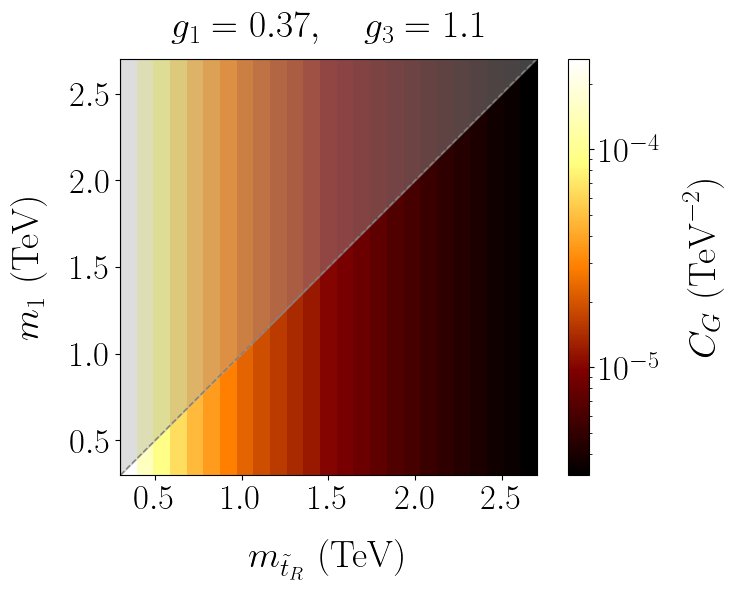

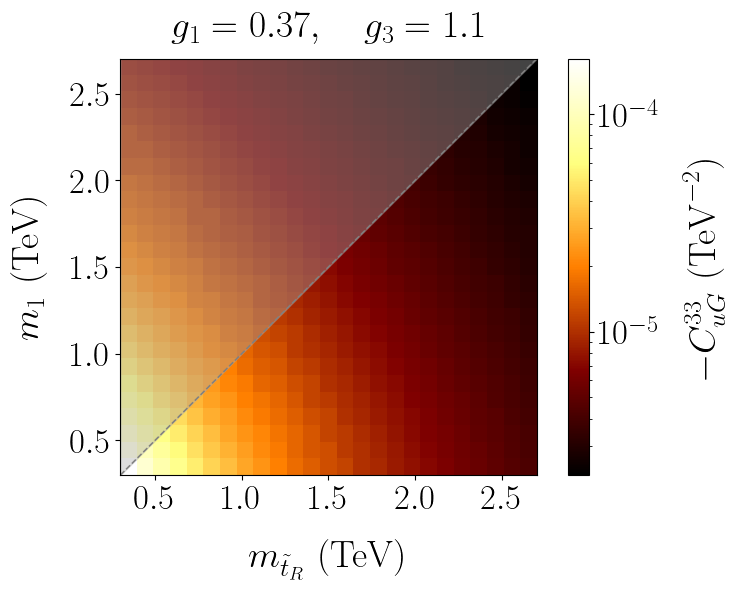

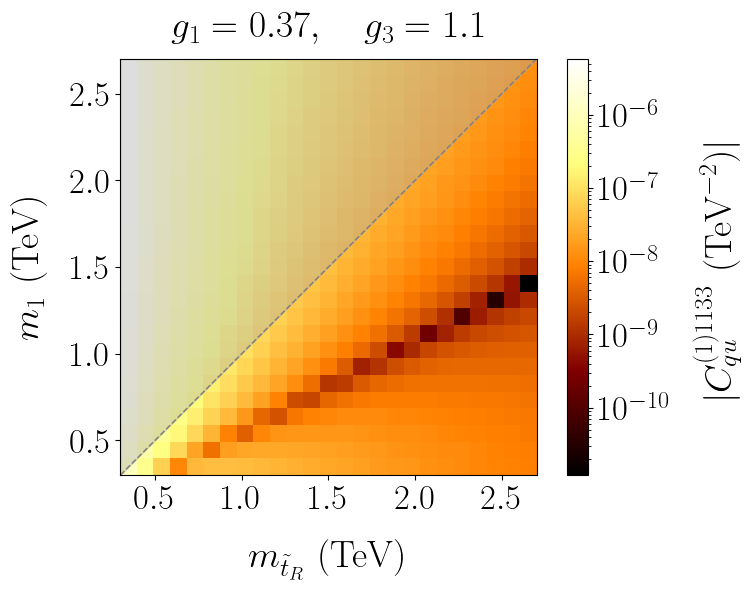

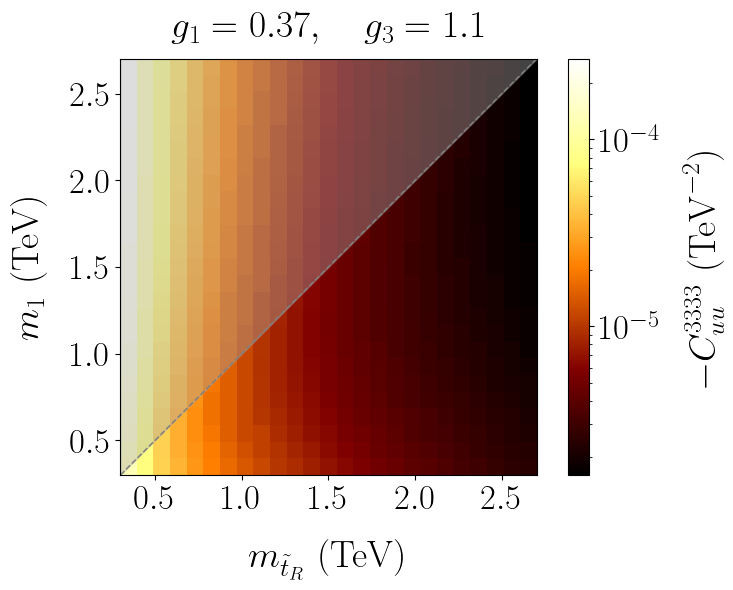

In [11]:
param_names = ['mut3','m1']

plot_fn_2d(data_grid, param_names, 'cG', "./plots/cG.pdf")
plot_fn_2d(data_grid, param_names, 'cuG_33', "./plots/cuG_33.pdf")
plot_fn_2d(data_grid, param_names, 'cqu1_1133', "./plots/cqu1_1133.pdf")
plot_fn_2d(data_grid, param_names, 'cuu_3333', "./plots/cuu_3333.pdf")

#### Bar Plot

##### Operators relevant for ttbar production

In [6]:
bp = [{'mut3': 2.0, 'm1': 1.5}, {'mut3': 1.6, 'm1': 1.5}, {'mut3': 1.6, 'm1': 0.5}]

kwargs_1 = {"bar_width": 0.2, "y_min": 1e-10, "y_max": 1e-4}

cols_1 = ['cG', 'cuG_33', 'cqu1_1133', 'cuu_3333', 'cqq1_3333', 'cqd1_3311', 'cqu8_3311', 'cqu8_1133']

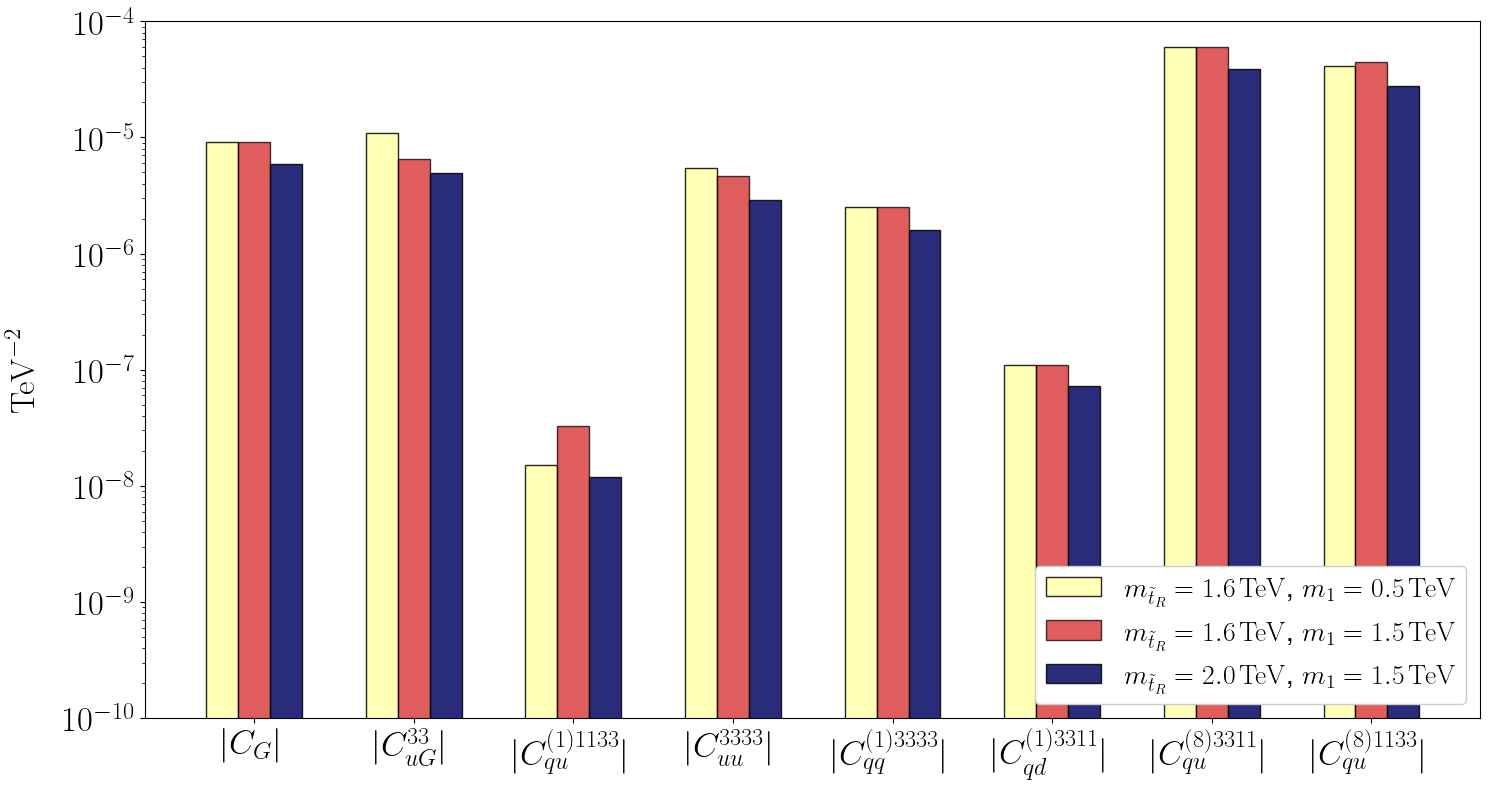

In [7]:
plot_fn_bar(data_grid,bp,cols_1,"./plots/barplot_sb.pdf",**kwargs_1)

##### Operators relevant for Higgs physics

In [8]:
cols_2 = ['cHBox', 'cHB', 'cHG', 'cuH_33', 'cHq1_33']

kwargs_2 = {"bar_width": 0.14, "y_min": 1e-9, "y_max": 1e-3}

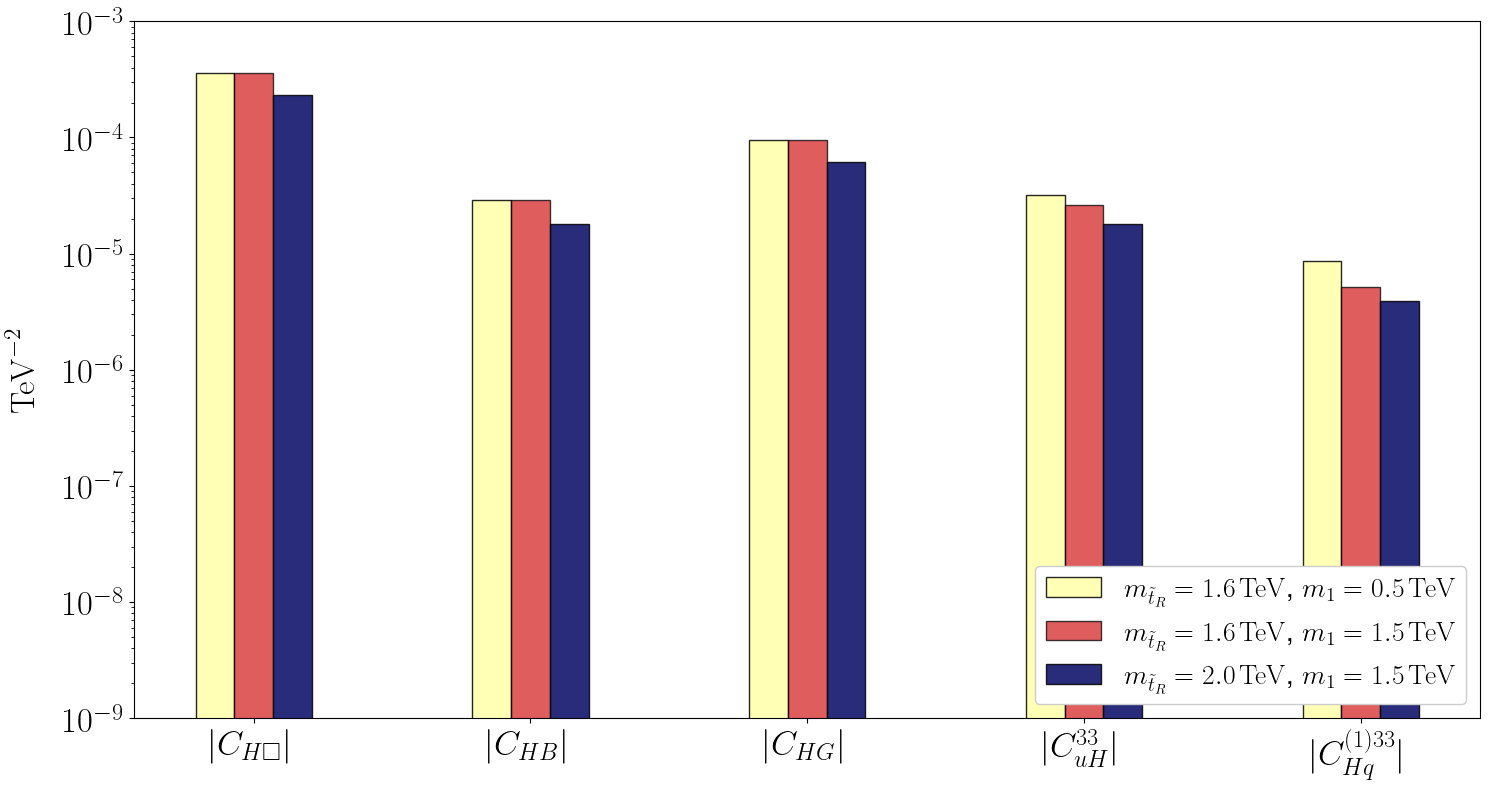

In [9]:
plot_fn_bar(data_grid,bp,cols_2,"./plots/barplot_h.pdf",**kwargs_2)